In [1]:
from google.cloud import bigquery
import pandas as pd

client = bigquery.Client(project="bionic-baton-496415-h5")

print("Connexion BigQuery réussie")

c:\Users\hp\AppData\Local\Programs\Python\Python311\Lib\site-packages\google\auth\_default.py:114: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


Connexion BigQuery réussie


# 📊 Notebook 1 — Statistiques Descriptives

## Price Intelligence Platform | Pr. ELAACHAK | 2025-2026

Objectif :
Analyser la distribution des prix et calculer les statistiques descriptives.

In [3]:
# ============================================================
# IMPORTS & CONFIGURATION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (12, 6),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.family': 'DejaVu Sans'
})

COLORS = {
    'jumia': '#E85D04',
    'marjane': '#2D6A4F',
    'micromagma': '#7B2D8B',
    'zara': '#1A1A2E',
    'primary': '#3A86FF',
    'secondary': '#FF6B6B'
}

print("✅ Imports OK")

Matplotlib is building the font cache; this may take a moment.


✅ Imports OK


In [8]:
import pandas as pd
import os

CSV_PATH = '../scrapers/data/cleaned_prices.csv'

if os.path.exists(CSV_PATH):

    df = pd.read_csv(CSV_PATH)

    df.columns = df.columns.str.lower().str.strip()

    if 'price' in df.columns:
        df = df.rename(columns={
            'price': 'price_mad',
            'source': 'source_platform',
            'category': 'category_normalized'
        })

    print(f"✅ Chargé depuis CSV: {len(df):,} lignes")

else:
    print("❌ CSV introuvable")

✅ Chargé depuis CSV: 2,990 lignes


In [9]:
df.head()

,name,price_mad,category_normalized,source_platform,url,scraped_at,source_label
0,"A07 – 6,7"" – 64 GB + 4 GB Ram – Green",949.0,smartphones,jumia,https://www.jumia.ma/samsung-a07-67-64-gb-4-gb...,2026-03-30 10:27:13.498929 UTC,Jumia Maroc
1,"A07 – 6,7"" – 64 GB + 4 GB Ram – Green",949.0,smartphones,jumia,https://www.jumia.ma/samsung-a07-67-64-gb-4-gb...,2026-03-30 10:27:13.498929 UTC,Jumia Maroc
2,Galaxy A16 8GB + 256GB - Black - 2 ans de gara...,1979.0,smartphones,jumia,https://www.jumia.ma/samsung-galaxy-a16-8gb-25...,2026-03-30 10:27:13.504469 UTC,Jumia Maroc
3,Galaxy A16 8GB + 256GB - Black - 2 ans de gara...,1979.0,smartphones,jumia,https://www.jumia.ma/samsung-galaxy-a16-8gb-25...,2026-03-30 10:27:13.504469 UTC,Jumia Maroc
4,Redmi Note 15 6GB 128GB Glacier Blue,2039.0,smartphones,jumia,https://www.jumia.ma/xiaomi-redmi-note-15-6gb-...,2026-03-30 10:27:13.506469 UTC,Jumia Maroc


In [11]:
print(df.columns)

Index(['name', 'price_mad', 'category_normalized', 'source_platform', 'url',
       'scraped_at', 'source_label'],
      dtype='object')


In [13]:
print("Shape :", df.shape)

print("\nTypes :")
print(df.dtypes)

print("\nValeurs manquantes :")
print(df.isnull().sum())

Shape : (2990, 7)

Types :
name                    object
price_mad              float64
category_normalized     object
source_platform         object
url                     object
scraped_at              object
source_label            object
dtype: object

Valeurs manquantes :
name                   0
price_mad              0
category_normalized    0
source_platform        0
url                    0
scraped_at             0
source_label           0
dtype: int64


In [14]:
df.columns = df.columns.str.lower().str.strip()

rename_map = {}

if 'price' in df.columns:
    rename_map['price'] = 'price_mad'

if 'source' in df.columns:
    rename_map['source'] = 'source_platform'

if 'category' in df.columns:
    rename_map['category'] = 'category_normalized'

df = df.rename(columns=rename_map)

print(df.columns)

Index(['name', 'price_mad', 'category_normalized', 'source_platform', 'url',
       'scraped_at', 'source_label'],
      dtype='object')


In [15]:
df['price_mad'].describe()

count     2990.000000
mean      3365.745980
std       5836.706106
min         19.000000
25%        179.000000
50%       1390.000000
75%       3799.000000
max      80776.000000
Name: price_mad, dtype: float64

In [19]:
print("Moyenne :", df['price_mad'].mean())
print("Médiane :", df['price_mad'].median())
print("Écart-type :", df['price_mad'].std())

Moyenne : 3365.7459799331104
Médiane : 1390.0
Écart-type : 5836.706106335666


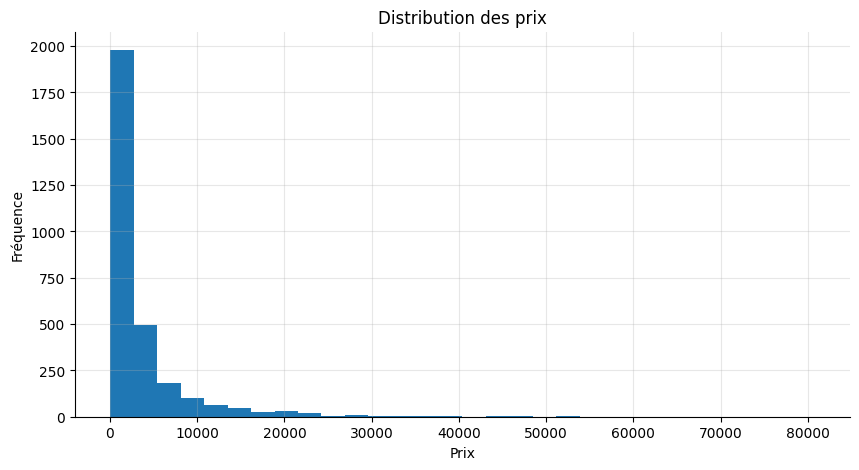

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(df['price_mad'], bins=30)

plt.title("Distribution des prix")
plt.xlabel("Prix")
plt.ylabel("Fréquence")

plt.show()

In [21]:
platform_stats = df.groupby('source_platform')['price_mad'].mean()

print(platform_stats)

source_platform
jumia         2113.648759
marjane       4762.544444
micromagma    8343.222962
zara           523.633333
Name: price_mad, dtype: float64


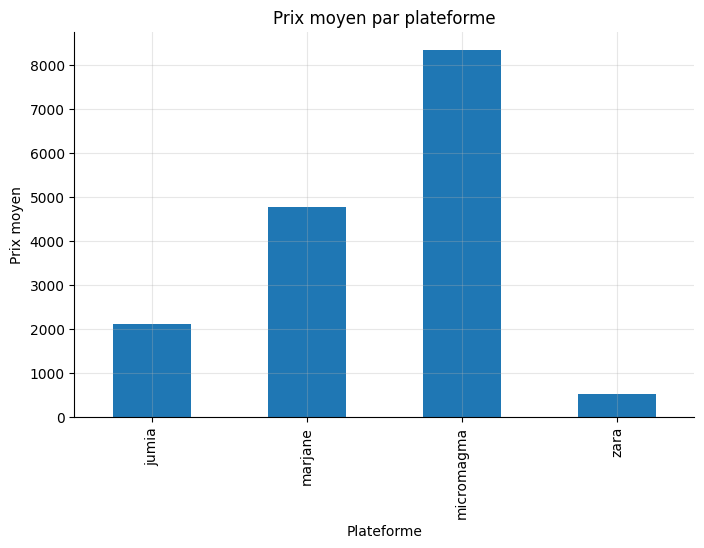

In [22]:
platform_stats.plot(kind='bar', figsize=(8,5))

plt.title("Prix moyen par plateforme")
plt.xlabel("Plateforme")
plt.ylabel("Prix moyen")

plt.show()

In [23]:
category_stats = df.groupby('category_normalized')['price_mad'].mean()

print(category_stats)

category_normalized
laptops        7457.627503
smartphones    2285.397025
tv             3859.137190
vetements       262.748035
Name: price_mad, dtype: float64


In [25]:
import os

# créer le dossier si nécessaire
os.makedirs('../scrapers/data', exist_ok=True)

summary = df.groupby(
    ['category_normalized', 'source_platform']
)['price_mad'].agg(
    ['mean', 'median', 'std', 'min', 'max']
)

summary.to_csv('../scrapers/data/clean_summary_stats.csv')

print("✅ CSV sauvegardé")

✅ CSV sauvegardé
